# Task (b) — Detector effects and the 10,000-event dataset

Task (a) produced *ideal* hits. Real detectors are imperfect, so we add two
effects and scale up.

## Effect 1 — efficiency
Each ideal hit is **recorded with probability 0.95**, independently. Events no
longer have a fixed hit count: a 10-track event has 50 ideal hits but records
only $50\times0.95 = 47.5$ on average. Per track, the recorded count follows
$\mathrm{Binomial}(5, 0.95)$.

## Effect 2 — position smearing
Each recorded hit's $x$ and $y$ get independent Gaussian noise. The spec says
"standard deviation of 0.1 percent"; we interpret this as **0.1% of the hit
radius**, $\sigma_x=\sigma_y = 0.001\,R$. This is isotropic, defensible as a
relative measurement precision, and avoids the axis degeneracy of a
per-coordinate reading. (The choice is a parameter, so it is easy to change.)

## Scale-up
Generate **10,000 events, 10 tracks each**, with these effects.


### Setup

In [1]:
import sys, os

def add_project_root_to_path():
    here = os.path.abspath(os.getcwd())
    while here != os.path.dirname(here):
        if os.path.isdir(os.path.join(here, "src")):
            if here not in sys.path: sys.path.insert(0, here)
            return here
        here = os.path.dirname(here)
    raise RuntimeError("Project root containing 'src/' not found.")
add_project_root_to_path()

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from math import comb
from src.simulator import simulate_event, simulate_events, detector_radii
from src.plotting import plot_event, draw_detector

RADII = detector_radii(5, 2.0); SMEAR = 0.001; EFF = 0.95

## 1. One realistic event
Ten tracks, only recorded hits — note tracks with fewer than 5 points (dropped hits).

recorded hits: 48 (ideal = 50)


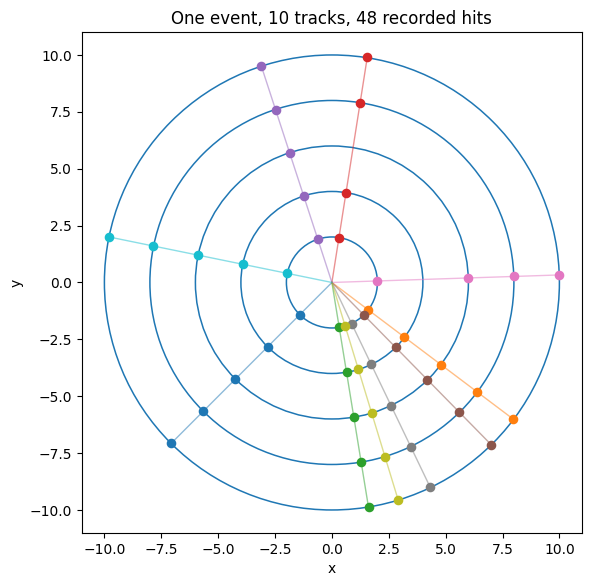

In [2]:
ev = simulate_event(0, n_tracks=10, efficiency=EFF, smear=SMEAR,
                    rng=np.random.default_rng(7))
print(f"recorded hits: {len(ev)} (ideal = 50)")
fig, ax = plt.subplots(figsize=(6.5, 6.5))
plot_event(ev, ax=ax, radii=RADII, legend=False)
ax.set_title(f"One event, 10 tracks, {len(ev)} recorded hits"); plt.show()

## 2. Generate the 10,000-event dataset
Saved to `data/` (git-ignored; regenerate from this cell).

In [3]:
df = simulate_events(10000, seed=2026, n_tracks=10, efficiency=EFF, smear=SMEAR)
os.makedirs("data", exist_ok=True)
df.to_csv("data/events_2d_10k.csv", index=False)
print(f"{len(df):,} hit rows from 10,000 events")
df.head()

475,028 hit rows from 10,000 events


,event_id,track_id,layer,x,y,phi
0,0,0,1,1.724846,3.606214,1.124281
1,0,0,2,2.594243,5.410960,1.124281
2,0,0,3,3.443609,7.211839,1.124281
3,0,0,4,4.324821,9.017249,1.124281
4,0,1,0,-1.278149,-1.539981,4.020693


## 3. Efficiency check — event level
Recorded hits per event scatter around $50\times0.95=47.5$.

mean hits/event: 47.5028


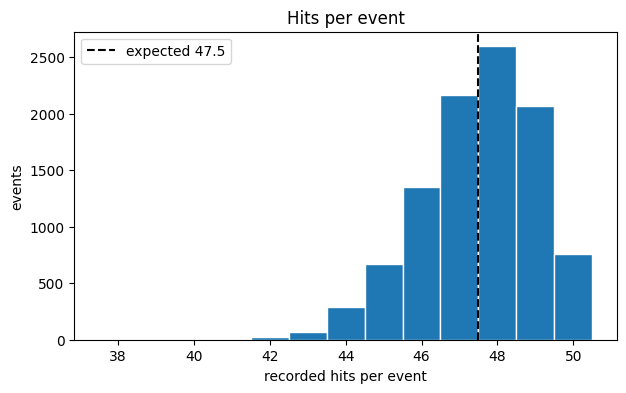

In [4]:
per_event = df.groupby("event_id").size()
print("mean hits/event:", per_event.mean())
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(per_event, bins=np.arange(38, 52)-0.5, color="tab:blue", edgecolor="white")
ax.axvline(47.5, color="k", ls="--", label="expected 47.5")
ax.set_xlabel("recorded hits per event"); ax.set_ylabel("events")
ax.set_title("Hits per event"); ax.legend(); plt.show()

## 4. Efficiency check — track level
Per-track multiplicity should match $\mathrm{Binomial}(5,0.95)$ exactly.

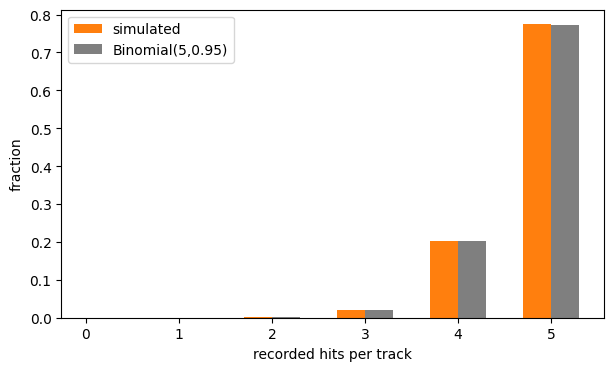

In [5]:
per_track = df.groupby(["event_id","track_id"]).size()
frac = per_track.value_counts(normalize=True).sort_index()
k = np.arange(0, 6)
binom = np.array([comb(5,i)*EFF**i*(1-EFF)**(5-i) for i in k])
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(frac.index-0.15, frac.values, width=0.3, label="simulated", color="tab:orange")
ax.bar(k+0.15, binom, width=0.3, label="Binomial(5,0.95)", color="tab:gray")
ax.set_xlabel("recorded hits per track"); ax.set_ylabel("fraction"); ax.set_xticks(k)
ax.legend(); plt.show()

## 5. Smearing, made visible
The noise ($\sigma \le 0.01$) is invisible next to the circle spacing of 2, so
we measure the *same* hit 3000 times: the spread is the Gaussian resolution, and
the outer hit ($R=10$) smears 5x more than the inner ($R=2$).

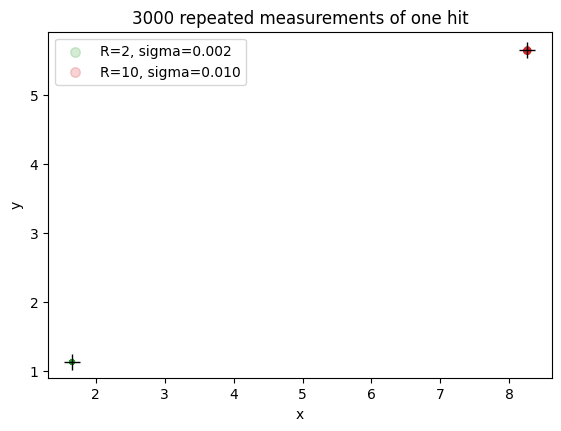

In [6]:
rng = np.random.default_rng(0); N = 3000; phi = 0.6
fig, ax = plt.subplots(figsize=(6.5, 6.5))
for R, col in [(2.0,"tab:green"), (10.0,"tab:red")]:
    x0, y0 = R*np.cos(phi), R*np.sin(phi); sig = SMEAR*R
    ax.scatter(x0+rng.normal(0,sig,N), y0+rng.normal(0,sig,N), s=3, alpha=0.2,
               color=col, label=f"R={R:.0f}, sigma={sig:.3f}")
    ax.plot(x0, y0, "k+", ms=12)
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("3000 repeated measurements of one hit"); ax.legend(markerscale=4); plt.show()

## 6. Smearing magnitude check\nRadial deviation divided by $\sigma=0.001R$ should be a standard normal.

std of normalized deviation: 1.0


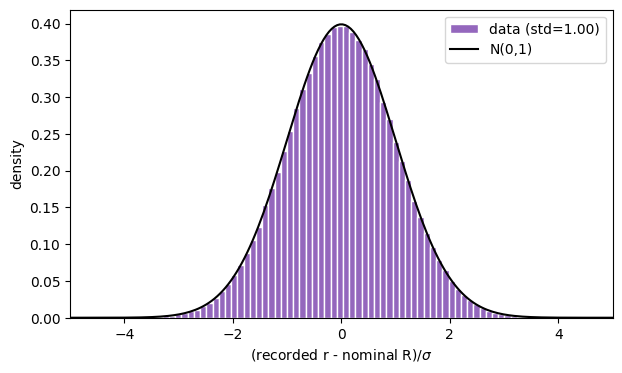

In [7]:
r = np.hypot(df["x"], df["y"]); nominal = RADII[df["layer"].to_numpy()]
dev = (r - nominal) / (SMEAR * nominal)
print("std of normalized deviation:", round(float(dev.std()), 3))
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(dev, bins=80, density=True, color="tab:purple", edgecolor="white",
        label=f"data (std={dev.std():.2f})")
xx = np.linspace(-5,5,200); ax.plot(xx, np.exp(-xx**2/2)/np.sqrt(2*np.pi), "k-",
                                     label="N(0,1)")
ax.set_xlabel(r"(recorded r - nominal R)/$\sigma$"); ax.set_ylabel("density")
ax.legend(); ax.set_xlim(-5,5); plt.show()

## Summary
* Two detector effects added: 95% per-hit efficiency (variable hit counts) and
  Gaussian smearing $\sigma=0.001R$.
* Verified statistically: hits/event ~ 47.5, hits/track ~ Binomial(5,0.95),
  normalized radial deviation ~ N(0,1).
* Dataset `data/events_2d_10k.csv` (475k rows) is the input for task (c)
  histograms and the training data for task (d).

**Next (task c):** histogram the distributions of hits and tracks in x, y and phi.